In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, mannwhitneyu, pointbiserialr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('default of credit card clients.csv', header=1)
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Grupos de Variáveis
pay_cols    = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols   = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
payamt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
numeric_cols = ['LIMIT_BAL','AGE'] + pay_cols + bill_cols + payamt_cols

print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df["DEFAULT"].mean():.2%}')

Dataset shape: (30000, 25)
Default rate: 22.12%



# Exercício 3 — Multicolinearidade


## 3.1 — Correlação de Pearson

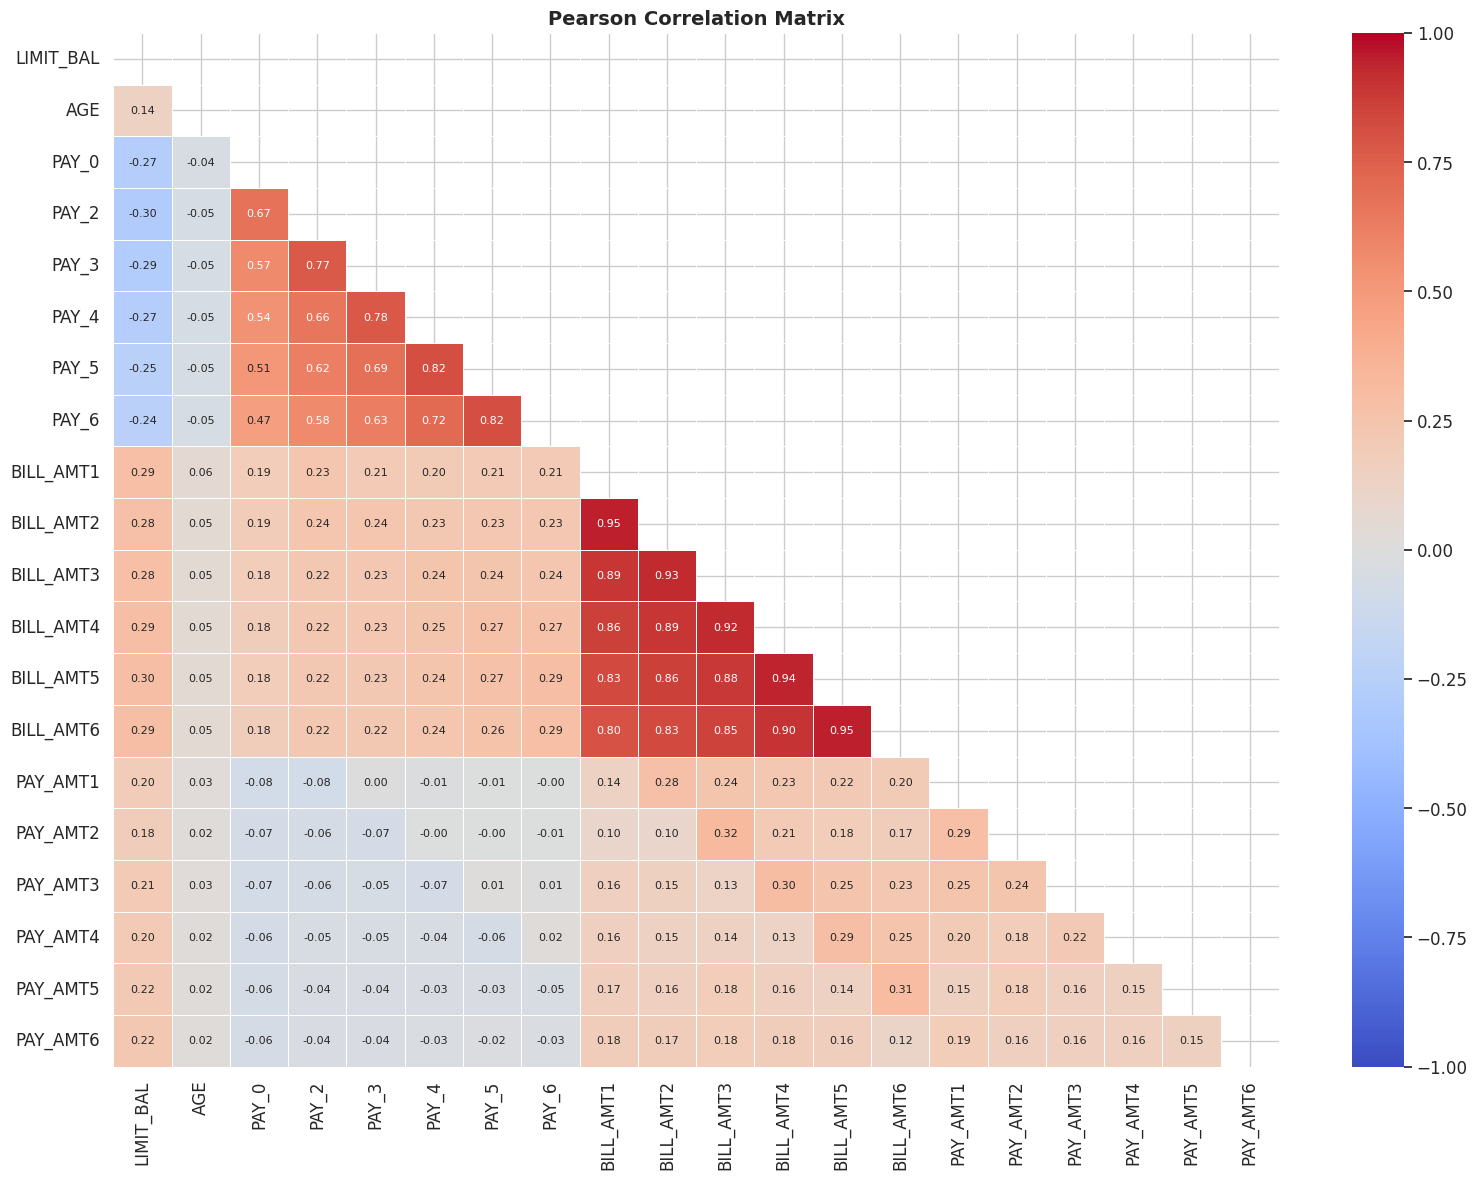


Multicolinearidade Forte
    Var A     Var B      r
BILL_AMT1 BILL_AMT2 0.9515
BILL_AMT5 BILL_AMT6 0.9462
BILL_AMT4 BILL_AMT5 0.9401
BILL_AMT2 BILL_AMT3 0.9283
BILL_AMT3 BILL_AMT4 0.9240
BILL_AMT4 BILL_AMT6 0.9009
BILL_AMT2 BILL_AMT4 0.8925
BILL_AMT1 BILL_AMT3 0.8923
BILL_AMT3 BILL_AMT5 0.8839
BILL_AMT1 BILL_AMT4 0.8603
BILL_AMT2 BILL_AMT5 0.8598
BILL_AMT3 BILL_AMT6 0.8533
BILL_AMT2 BILL_AMT6 0.8316
BILL_AMT1 BILL_AMT5 0.8298
    PAY_4     PAY_5 0.8198
    PAY_5     PAY_6 0.8169
BILL_AMT1 BILL_AMT6 0.8027


In [ ]:
corr = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print('\nMulticolinearidade Forte')
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            high_corr.append({'Var A': corr.columns[i], 'Var B': corr.columns[j], 'r': round(r, 4)})

hc_df = pd.DataFrame(high_corr).sort_values('r', ascending=False)
print(hc_df.to_string(index=False))

## 3.2 — Variance Inflation Factor (VIF)


=== Variance Inflation Factor (VIF) ===
 Variable   VIF
BILL_AMT2 25.86
BILL_AMT5 24.99
BILL_AMT3 21.77
BILL_AMT4 20.35
BILL_AMT6 15.02
BILL_AMT1 14.02
    PAY_5  4.72
    PAY_4  4.29
    PAY_3  3.66
    PAY_6  3.26
    PAY_2  3.17
 PAY_AMT2  2.24
    PAY_0  1.92
 PAY_AMT3  1.76
 PAY_AMT1  1.71
 PAY_AMT5  1.69
 PAY_AMT4  1.65
LIMIT_BAL  1.47
 PAY_AMT6  1.17
      AGE  1.02


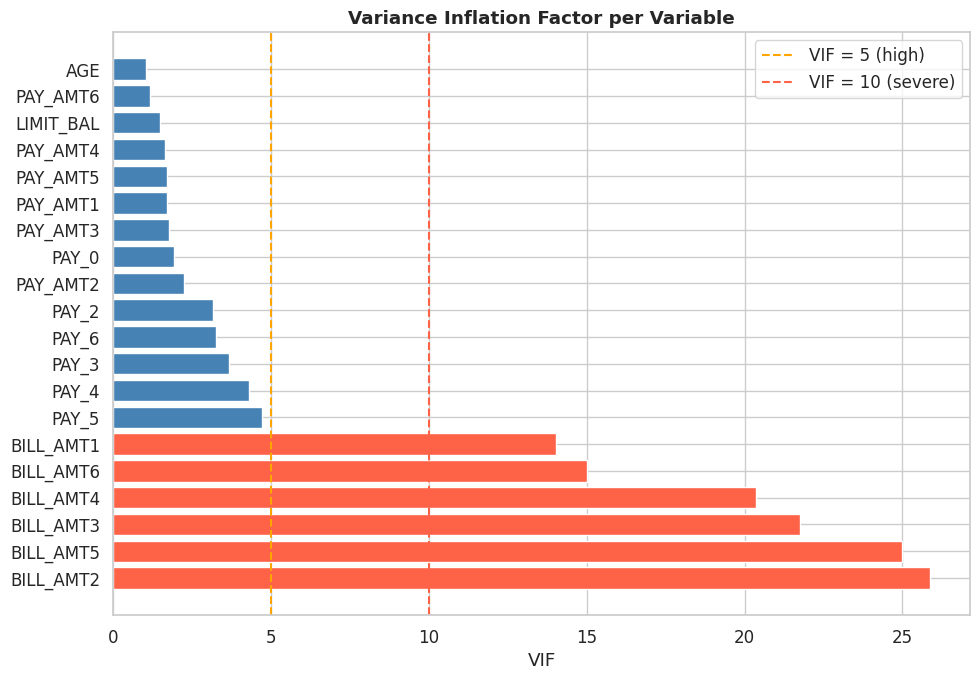

In [4]:
from numpy.linalg import lstsq

def compute_vif(df_subset):
    """Compute VIF for each column using OLS R²."""
    X = df_subset.values
    vif_values = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        # Add intercept
        X_others = np.column_stack([np.ones(len(y)), X_others])
        coeffs, _, _, _ = lstsq(X_others, y, rcond=None)
        y_pred = X_others @ coeffs
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_values.append(vif)
    return vif_values

# Use a clean subset (drop near-zero variance cols)
vif_cols = numeric_cols.copy()
df_vif = df[vif_cols].copy()

vif_vals = compute_vif(df_vif)
vif_df = pd.DataFrame({'Variable': vif_cols, 'VIF': [round(v, 2) for v in vif_vals]})
vif_df = vif_df.sort_values('VIF', ascending=False)

print('=== Variance Inflation Factor (VIF) ===')
print(vif_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors_vif = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vif_df['VIF']]
ax.barh(vif_df['Variable'], vif_df['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (high)')
ax.axvline(10, color='tomato',  linestyle='--', linewidth=1.5, label='VIF = 10 (severe)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor per Variable', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 — PCA Eigenvalue



Condition number: 281.5
Number of components to explain 90% variance: 10
Number of components to explain 95% variance: 12
Total variables: 20


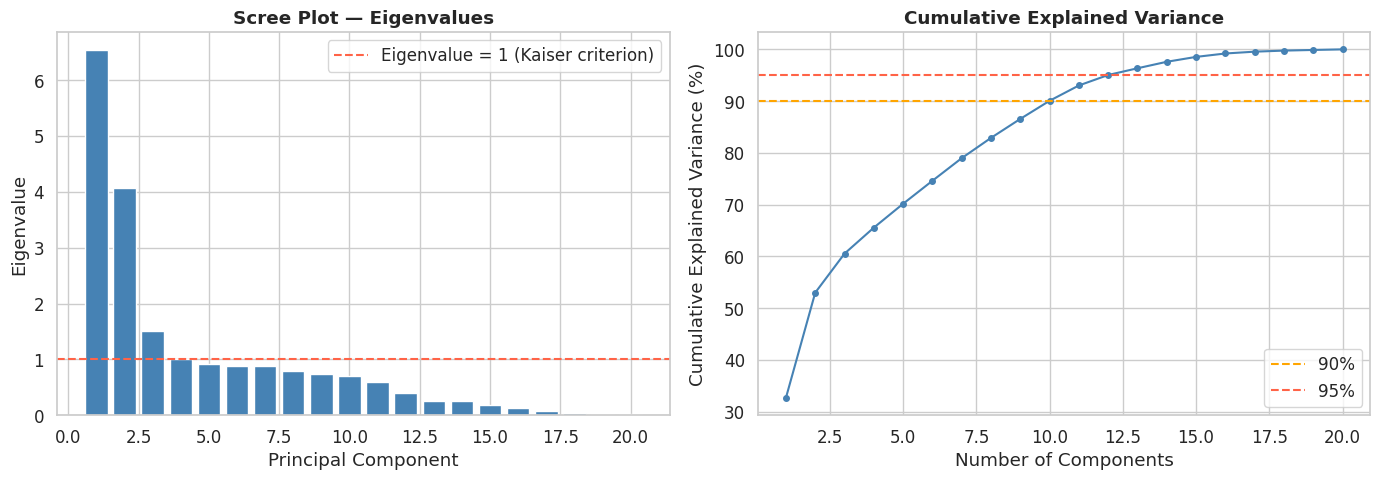

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

pca = PCA()
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
explained   = pca.explained_variance_ratio_
cumulative  = np.cumsum(explained)

condition_number = eigenvalues.max() / eigenvalues.min()
print(f'Condition number: {condition_number:.1f}')
print(f'Number of components to explain 90% variance: {np.argmax(cumulative >= 0.90) + 1}')
print(f'Number of components to explain 95% variance: {np.argmax(cumulative >= 0.95) + 1}')
print(f'Total variables: {len(numeric_cols)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues, color='steelblue', edgecolor='white')
axes[0].axhline(1, color='tomato', linestyle='--', label='Eigenvalue = 1 (Kaiser criterion)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot — Eigenvalues', fontweight='bold')
axes[0].legend()

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100,
             marker='o', markersize=4, color='steelblue')
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].axhline(95, color='tomato',  linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.4 — Análise Multicolinearidade

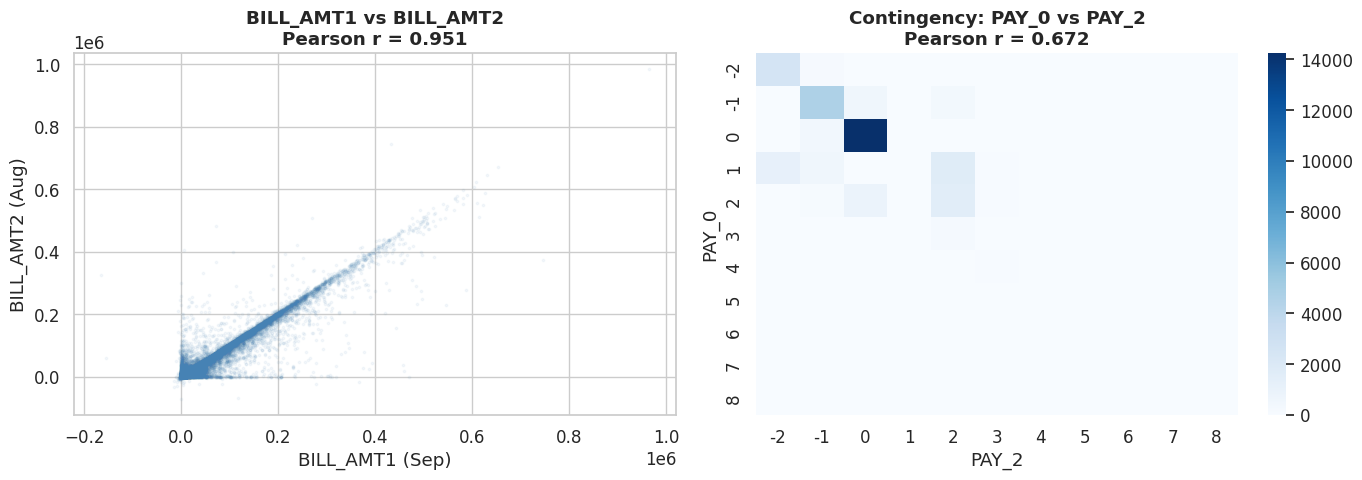

In [6]:
# Demonstrate the autocorrelation structure of BILL_AMT
bill_corr = df[bill_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BILL_AMT month-to-month scatter
axes[0].scatter(df['BILL_AMT1'], df['BILL_AMT2'], alpha=0.05, s=3, color='steelblue')
axes[0].set_xlabel('BILL_AMT1 (Sep)')
axes[0].set_ylabel('BILL_AMT2 (Aug)')
r_b, _ = stats.pearsonr(df['BILL_AMT1'], df['BILL_AMT2'])
axes[0].set_title(f'BILL_AMT1 vs BILL_AMT2\nPearson r = {r_b:.3f}', fontweight='bold')

# PAY_0 vs PAY_2
ct = pd.crosstab(df['PAY_0'], df['PAY_2'])
sns.heatmap(ct, cmap='Blues', ax=axes[1], annot=False, cbar=True)
r_p, _ = stats.pearsonr(df['PAY_0'], df['PAY_2'])
axes[1].set_title(f'Contingency: PAY_0 vs PAY_2\nPearson r = {r_p:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

---
# Exercise 4 — Outliers Multivariávies


## 4.1 — Univariate Outliers (IQR method)

In [7]:
# Use a focused subset for multivariate analysis
mv_cols = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0', 'AGE']
df_mv = df[mv_cols].copy()

# --- Univariate outliers using IQR ---
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

uni_outlier_mask = pd.Series(False, index=df.index)
print('=== Univariate Outlier Counts (IQR method, 1.5×IQR) ===')
for col in mv_cols:
    mask = iqr_outliers(df_mv[col])
    uni_outlier_mask = uni_outlier_mask | mask
    print(f'  {col:15s}: {mask.sum():5d} outliers ({mask.mean():.2%})')

print(f'\nUnion — at least 1 univariate outlier: {uni_outlier_mask.sum()} ({uni_outlier_mask.mean():.2%})')

=== Univariate Outlier Counts (IQR method, 1.5×IQR) ===
  LIMIT_BAL      :   167 outliers (0.56%)
  BILL_AMT1      :  2400 outliers (8.00%)
  PAY_AMT1       :  2745 outliers (9.15%)
  PAY_0          :  3130 outliers (10.43%)
  AGE            :   272 outliers (0.91%)

Union — at least 1 univariate outlier: 7511 (25.04%)


## 4.2 — Distância de Mahalanobis

In [8]:
def mahalanobis_distance(X):
    """Compute Mahalanobis distance for each row of X."""
    mu = X.mean(axis=0)
    cov = np.cov(X.T)
    cov_inv = np.linalg.pinv(cov)  # pseudo-inverse for robustness
    diff = X - mu
    # D²_M = (x-mu)^T * Sigma^-1 * (x-mu)
    d2 = np.array([diff[i] @ cov_inv @ diff[i] for i in range(len(X))])
    return np.sqrt(d2)

X_mv = df_mv.values.astype(float)
maha = mahalanobis_distance(X_mv)

p = len(mv_cols)
# Chi² threshold: p=5 variables, significance level 0.001
threshold_001 = np.sqrt(chi2.ppf(0.999, df=p))
threshold_0001 = np.sqrt(chi2.ppf(0.9999, df=p))

multi_outlier_mask_001  = maha > threshold_001
multi_outlier_mask_0001 = maha > threshold_0001

print(f'Chi² threshold (α=0.001, p={p}): D_M > {threshold_001:.2f}')
print(f'Chi² threshold (α=0.0001, p={p}): D_M > {threshold_0001:.2f}')
print(f'\nMultivariate outliers (α=0.001):  {multi_outlier_mask_001.sum()} ({multi_outlier_mask_001.mean():.2%})')
print(f'Multivariate outliers (α=0.0001): {multi_outlier_mask_0001.sum()} ({multi_outlier_mask_0001.mean():.2%})')

Chi² threshold (α=0.001, p=5): D_M > 4.53
Chi² threshold (α=0.0001, p=5): D_M > 5.07

Multivariate outliers (α=0.001):  623 (2.08%)
Multivariate outliers (α=0.0001): 431 (1.44%)


## 4.3 — Multivariate Outliers NOT Univariate

In [9]:
# Pure multivariate outliers: flagged by Mahalanobis but NOT by any univariate IQR
pure_mv_outliers = multi_outlier_mask_001 & ~uni_outlier_mask

print(f'Pure multivariate outliers (Mahalanobis only, NOT univariate): {pure_mv_outliers.sum()}')
print(f'Overlap (both methods):  {(multi_outlier_mask_001 & uni_outlier_mask).sum()}')
print(f'Univariate only:         {(~multi_outlier_mask_001 & uni_outlier_mask).sum()}')

# Show some examples of pure multivariate outliers
print('\n=== Sample of Pure Multivariate Outliers ===')
examples = df_mv[pure_mv_outliers].head(10).copy()
examples['Mahalanobis_D'] = maha[pure_mv_outliers][:10]
print(examples.to_string())

Pure multivariate outliers (Mahalanobis only, NOT univariate): 0
Overlap (both methods):  623
Univariate only:         6888

=== Sample of Pure Multivariate Outliers ===
Empty DataFrame
Columns: [LIMIT_BAL, BILL_AMT1, PAY_AMT1, PAY_0, AGE, Mahalanobis_D]
Index: []


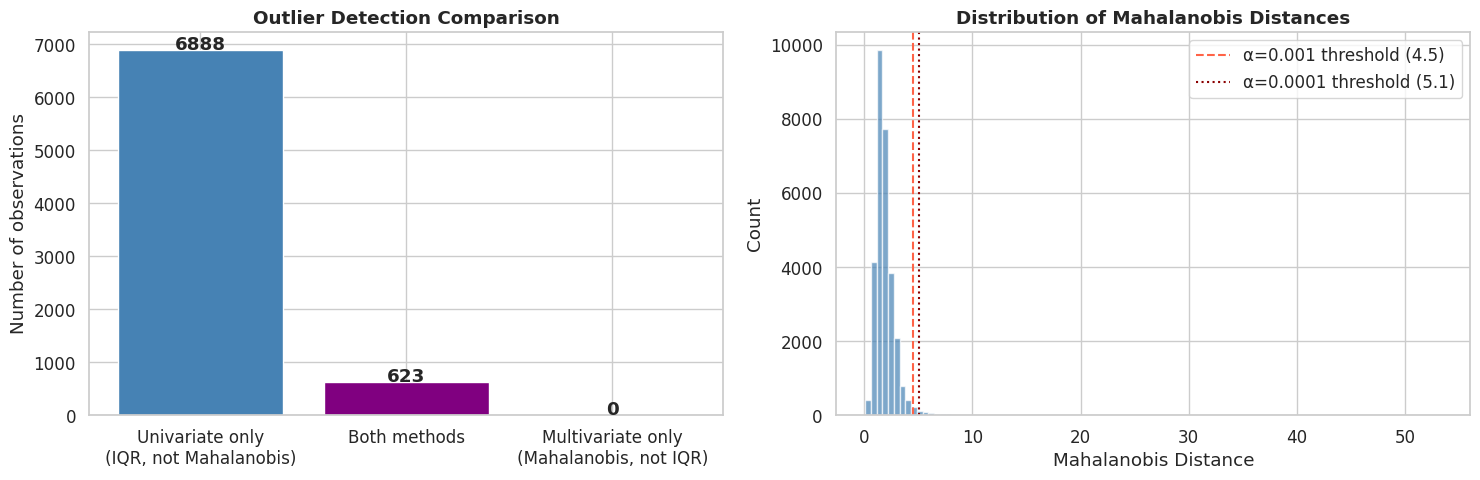

In [10]:
# Venn-style bar chart
categories = {
    'Univariate only\n(IQR, not Mahalanobis)': (~multi_outlier_mask_001 & uni_outlier_mask).sum(),
    'Both methods': (multi_outlier_mask_001 & uni_outlier_mask).sum(),
    'Multivariate only\n(Mahalanobis, not IQR)': pure_mv_outliers.sum(),
    'Not outlier (either)': (~multi_outlier_mask_001 & ~uni_outlier_mask).sum()
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
labels_bar = list(categories.keys())[:3]
values_bar = list(categories.values())[:3]
axes[0].bar(labels_bar, values_bar,
            color=['steelblue', 'purple', 'tomato'], edgecolor='white')
axes[0].set_title('Outlier Detection Comparison', fontweight='bold')
axes[0].set_ylabel('Number of observations')
for i, v in enumerate(values_bar):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Mahalanobis distance distribution
axes[1].hist(maha, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(threshold_001, color='tomato', linestyle='--',
                label=f'α=0.001 threshold ({threshold_001:.1f})')
axes[1].axvline(threshold_0001, color='darkred', linestyle=':',
                label=f'α=0.0001 threshold ({threshold_0001:.1f})')
axes[1].set_xlabel('Mahalanobis Distance')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Mahalanobis Distances', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

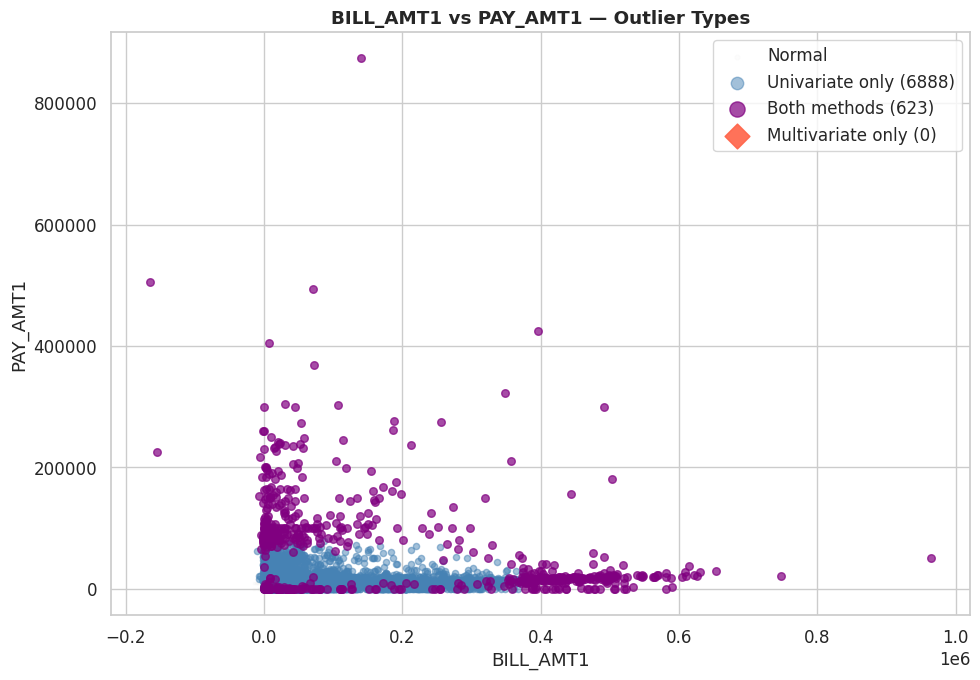

In [11]:
# Scatter: BILL_AMT1 vs PAY_AMT1 highlighting the different outlier types
fig, ax = plt.subplots(figsize=(10, 7))

normal   = ~multi_outlier_mask_001 & ~uni_outlier_mask
uni_only = ~multi_outlier_mask_001 & uni_outlier_mask
both     = multi_outlier_mask_001 & uni_outlier_mask
mv_only  = pure_mv_outliers

ax.scatter(df_mv.loc[normal,   'BILL_AMT1'], df_mv.loc[normal,   'PAY_AMT1'],
           alpha=0.05, s=3, color='lightgrey', label='Normal')
ax.scatter(df_mv.loc[uni_only, 'BILL_AMT1'], df_mv.loc[uni_only, 'PAY_AMT1'],
           alpha=0.5, s=20, color='steelblue', label=f'Univariate only ({uni_only.sum()})')
ax.scatter(df_mv.loc[both,     'BILL_AMT1'], df_mv.loc[both,     'PAY_AMT1'],
           alpha=0.7, s=30, color='purple',    label=f'Both methods ({both.sum()})')
ax.scatter(df_mv.loc[mv_only,  'BILL_AMT1'], df_mv.loc[mv_only,  'PAY_AMT1'],
           alpha=0.9, s=40, color='tomato',    label=f'Multivariate only ({mv_only.sum()})', marker='D')

ax.set_xlabel('BILL_AMT1')
ax.set_ylabel('PAY_AMT1')
ax.set_title('BILL_AMT1 vs PAY_AMT1 — Outlier Types', fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
# Exercise 5 — Hypothesis About Variable (In)dependence

Based on the exploratory analysis, we pose and formally test two hypotheses:

**H1:** *PAY_0 (repayment status in September) and DEFAULT are dependent* — clients with payment delays are more likely to default.

**H2:** *LIMIT_BAL and DEFAULT are dependent* — clients with higher credit limits are less likely to default.

For each hypothesis we define H₀ (independence/no difference) and Hₐ (dependence/difference), choose the appropriate test, and interpret the result.

## 5.1 — H1: PAY_0 e DEFAULT são dependentes?

**Test:** Qui-quadrado de independência (Cramér) 
**H₀:** PAY_0 and DEFAULT são independentes 
**α = 0.05**

In [13]:
# Contingency table
ct = pd.crosstab(df['PAY_0'], df['DEFAULT'])
ct.columns = ['No Default', 'Default']

chi2_stat, p_val, dof, expected = stats.chi2_contingency(ct)

# Cramér's V — effect size for chi²
n = ct.values.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(ct.shape) - 1)))

print('=== Chi-Squared Test: PAY_0 vs DEFAULT ===')
print(f'χ² statistic : {chi2_stat:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value      : {p_val:.2e}')
print(f"Cramér's V   : {cramers_v:.4f}")
print()
print('Decision: REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀')
print('PAY_0 and DEFAULT are DEPENDENT' if p_val < 0.05 else 'No evidence of dependence')

# Default rate by PAY_0
ct_pct = pd.crosstab(df['PAY_0'], df['DEFAULT'], normalize='index') * 100
ct_pct.columns = ['No Default (%)', 'Default (%)']
print('\nDefault rate by PAY_0 value:')
print(ct_pct.round(1))

=== Chi-Squared Test: PAY_0 vs DEFAULT ===
χ² statistic : 5365.96
Degrees of freedom: 10
p-value      : 0.00e+00
Cramér's V   : 0.4229

Decision: REJECT H₀
PAY_0 and DEFAULT are DEPENDENT

Default rate by PAY_0 value:
       No Default (%)  Default (%)
PAY_0                             
-2               86.8         13.2
-1               83.2         16.8
 0               87.2         12.8
 1               66.1         33.9
 2               30.9         69.1
 3               24.2         75.8
 4               31.6         68.4
 5               50.0         50.0
 6               45.5         54.5
 7               22.2         77.8
 8               42.1         57.9


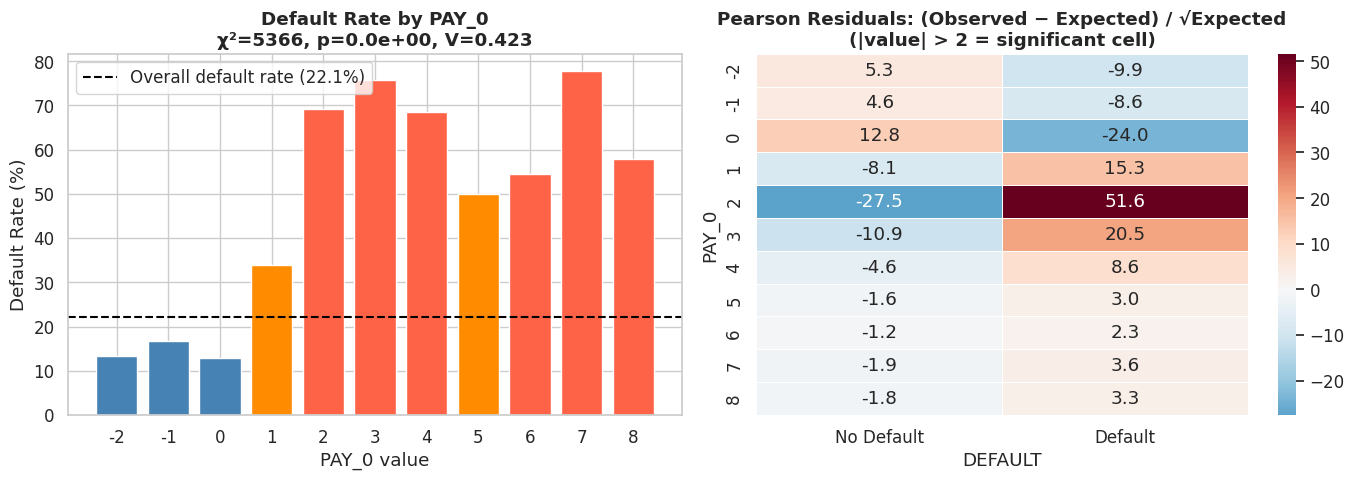

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by PAY_0
default_rate = ct_pct['Default (%)']
bar_colors = ['tomato' if v > 50 else 'darkorange' if v > 25 else 'steelblue'
              for v in default_rate]
axes[0].bar(default_rate.index.astype(str), default_rate.values,
            color=bar_colors, edgecolor='white')
axes[0].set_xlabel('PAY_0 value')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title(f'Default Rate by PAY_0\nχ²={chi2_stat:.0f}, p={p_val:.1e}, V={cramers_v:.3f}',
                  fontweight='bold')
axes[0].axhline(df['DEFAULT'].mean()*100, color='black', linestyle='--',
                label=f'Overall default rate ({df["DEFAULT"].mean():.1%})')
axes[0].legend()

# Heatmap of contingency table (observed vs expected)
residuals = (ct.values - expected) / np.sqrt(expected)
res_df = pd.DataFrame(residuals, index=ct.index, columns=ct.columns)
sns.heatmap(res_df, annot=True, fmt='.1f', cmap='RdBu_r',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Pearson Residuals: (Observed − Expected) / √Expected\n(|value| > 2 = significant cell)',
                  fontweight='bold')
axes[1].set_xlabel('DEFAULT')
axes[1].set_ylabel('PAY_0')

plt.tight_layout()
plt.show()

## 5.2 — H2: LIMIT_BAL e DEFAULT são dependentes? 

**Test:** Mann-Whitney U teste 
**α = 0.05**



In [10]:
group0 = df.loc[df['DEFAULT']==0, 'LIMIT_BAL']
group1 = df.loc[df['DEFAULT']==1, 'LIMIT_BAL']

u_stat, p_mw = mannwhitneyu(group0, group1, alternative='two-sided')

# Effect size: r = Z / sqrt(N)
n0, n1 = len(group0), len(group1)
r_effect = abs(u_stat / (n0 * n1) - 0.5) * 2  # rank-biserial correlation

# Also compute point-biserial correlation
rpb, p_rpb = pointbiserialr(df['DEFAULT'], df['LIMIT_BAL'])

print('=== Mann-Whitney U Test: LIMIT_BAL vs DEFAULT ===')
print(f'U statistic      : {u_stat:.0f}')
print(f'p-value          : {p_mw:.2e}')
print(f'Rank-biserial r  : {r_effect:.4f}')
print(f'Point-biserial r : {rpb:.4f} (p={p_rpb:.2e})')
print()
print(f'Median LIMIT_BAL — No Default: {group0.median():,.0f} NT$')
print(f'Median LIMIT_BAL — Default   : {group1.median():,.0f} NT$')
print()
print('Decision: REJECT H₀' if p_mw < 0.05 else 'FAIL TO REJECT H₀')
print('LIMIT_BAL and DEFAULT are DEPENDENT' if p_mw < 0.05 else 'No evidence of dependence')

=== Mann-Whitney U Test: LIMIT_BAL vs DEFAULT ===
U statistic      : 95786286
p-value          : 1.23e-189
Rank-biserial r  : 0.2356
Point-biserial r : -0.1535 (p=1.30e-157)

Median LIMIT_BAL — No Default: 150,000 NT$
Median LIMIT_BAL — Default   : 90,000 NT$

Decision: REJECT H₀
LIMIT_BAL and DEFAULT are DEPENDENT


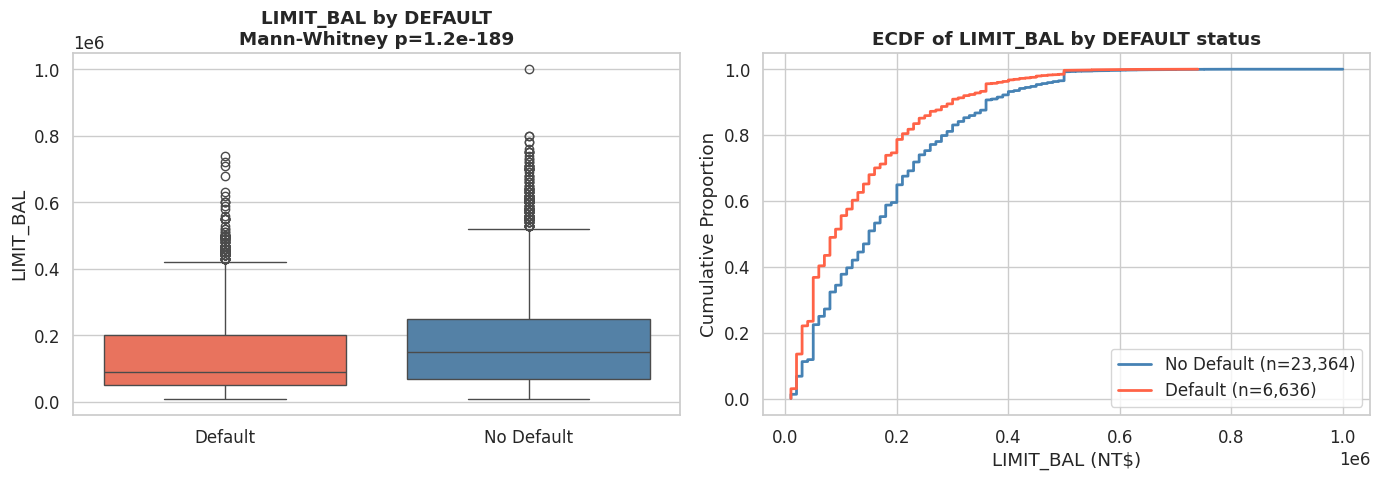

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot['DEFAULT_LABEL'] = df_plot['DEFAULT'].map({0: 'No Default', 1: 'Default'})

# Box plot
sns.boxplot(data=df_plot, x='DEFAULT_LABEL', y='LIMIT_BAL',
            palette={'No Default': 'steelblue', 'Default': 'tomato'}, ax=axes[0])
axes[0].set_title(f'LIMIT_BAL by DEFAULT\nMann-Whitney p={p_mw:.1e}', fontweight='bold')
axes[0].set_xlabel('')

# ECDF
for grp, label, color in [(group0, 'No Default', 'steelblue'), (group1, 'Default', 'tomato')]:
    sorted_vals = np.sort(grp)
    ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    axes[1].plot(sorted_vals, ecdf, label=f'{label} (n={len(grp):,})', color=color, linewidth=2)

axes[1].set_xlabel('LIMIT_BAL (NT$)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('ECDF of LIMIT_BAL by DEFAULT status', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()